In [ ]:
!pip install "numpy<2"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [4]:
df.shape

(100, 3)

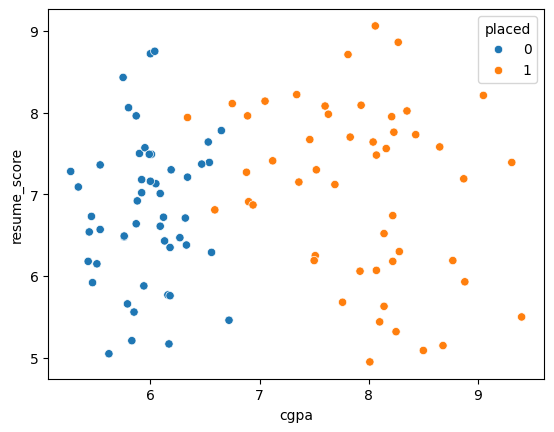

In [5]:
sns.scatterplot(data=df, x='cgpa', y='resume_score', hue='placed')
plt.show()

In [6]:
X = df.iloc[:,:2].values
y = df.iloc[:,-1].values

In [7]:
print(X.shape)
print(y.shape)

(100, 2)
(100,)


In [8]:
from sklearn.linear_model import Perceptron

In [9]:
perceptron = Perceptron()

In [10]:
perceptron.fit(X,y)

Perceptron()

In [11]:
print(perceptron.coef_)      # 2D --> 1D
print(perceptron.intercept_) # 1D --> value

[[ 40.26 -36.  ]]
[-25.]


In [12]:
w = perceptron.coef_[0]  # [ w0 w1]

In [13]:
w

array([ 40.26, -36.  ])

In [14]:
b = perceptron.intercept_[0] # b

In [15]:
b

np.float64(-25.0)

In [16]:
# w0.x + w1.y + b = 0
# y = mx + c
m = -(w[0]/w[1])
c = -b /w[1]

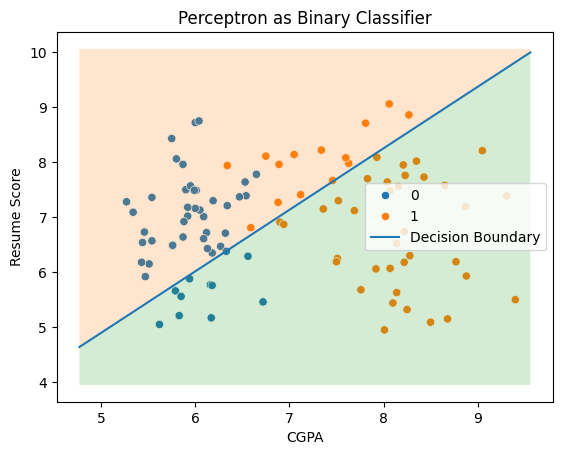

In [17]:
x_vals = np.linspace(df['cgpa'].min() - 0.5, df['resume_score'].max() + 0.5, 100)
y_vals = m * x_vals + c
# Plot data points
sns.scatterplot(data=df, x='cgpa', y='resume_score', hue='placed')
# Plot decision boundary
plt.plot(x_vals, y_vals, label="Decision Boundary")
# regions
plt.fill_between(x_vals, y_vals, df['resume_score'].max() + 1, alpha=0.2)  # above region
plt.fill_between(x_vals, y_vals, df['resume_score'].min() - 1, alpha=0.2)  # below region
plt.xlabel("CGPA")
plt.ylabel("Resume Score")
plt.legend()
plt.title("Perceptron as Binary Classifier")
plt.show()